In [69]:
import matplotlib.pyplot as plt
import numpy
import pandas
import functools 
import datetime
import scipy

import pmana.utils
import pmana.purity

#### Look at the purity of one measurement

There were 4 used channels in this measurement.


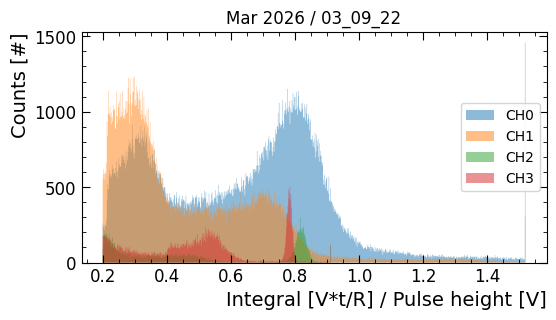

In [3]:
fig, ax = plt.subplots(figsize=(6,3))

YEAR = '2026'
MONTH = 'Mar'
MEASUREMENT = f'03_09_22'
FILE_PATH = f"../../data/cern_csv/{YEAR}_{MONTH}/Record_{YEAR}_{MONTH}_{MEASUREMENT}.csv"
# extract a measurement 
Data = pmana.utils.io.ExtractSingleMeasurement(
    FILE_PATH,
    IS_CSV = True,
    COL_NAMES = ['binCenter', 'F1', 'F2', 'F3', 'F4'],
    DELIMITER = ","
)
print(f"There were {len(Data)} used channels in this measurement.")

CHs = [1, 2, 3, 4]
for ch in CHs:
    # plot channel data
    pmana.utils.plotting.PlotSingleChannel(
        Data[ch-1],
        ax,
        channel = ch-1,
        rebin = False,
        debug = False,
        DISPLAY_FIT = False
    )

ax = pmana.utils.plotting.UpdateMatplotlibStyle(
    ax,
    "Integral [V*t/R] / Pulse height [V]",
    "Counts [#]"
)

ax.legend()
ax.set_title(f"{MONTH} {YEAR} / {MEASUREMENT}")
plt.show()
fig.savefig(f"../../plots/cern/RawData_{YEAR}_{MONTH}.png", dpi=300, bbox_inches='tight')

In [60]:
CalibrationFactors = {
  0: 1,
  1: 1,
  2: 0.8,
  3: 0.8
}

ANALYSIS_CONFIGURATION = {
    'InnerLongChannel'          : 0,
    'OuterLongChannel'          : 1,
    'InnerShortChannel'         : 3,
    'OuterShortChannel'         : 2,  
    'ShortGausFitLimits'        : (0.15, 0.15),
    'LongGausFitLimits'         : (0.1, 0.15),
    'ComptonSearchLimits'       : (0.5, 1),
    'MinComptonSearchLowLimit'  : 0.25,
    'ComptonMode'               : 'rising'
}

pmana.purity.ana.ExtractICPeak(
  FILE_PATH,
  CalibrationFactors,
  PM_TAG = 'Long',
  ANALYSIS_CONFIGURATION = ANALYSIS_CONFIGURATION
)

Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_05_12.csv...


[np.float64(0.8272615682018317),
 np.float64(0.0009330010648135016),
 np.float64(1.2655560016057807)]

#### Purity analysis

In [72]:
# get temperatures
PATH_TEMPERATURES = f"../../data/cern_csv/NP02_Temp.csv"

Temperatures = pmana.utils.io.ExtractTemperatureMonitoring(
    PATH_TEMPERATURES,
    IsPadova = False,
    delimiter = "\t",
    skiprows = 1,
    # usecols = [0, 1],
    names = ["Date", "T"]
)

# some more formatting...
Temperatures['Date'] = pandas.to_datetime(
    Temperatures['Date'],
    unit='ms',
    utc=True
)
Temperatures = Temperatures.drop_duplicates()
Temperatures = Temperatures.sort_values(by=['Date'])

In [73]:
# analyze campaign
TIME_DIR = f"2026_Mar"
PATH_CAMPAIGN = f"../../data/cern_csv/{TIME_DIR}"

CalibrationFactors = {
  0: 1,
  1: 1,
  2: 0.8,
  3: 0.8
}

ANALYSIS_CONFIGURATION = {
    'InnerLongChannel'          : 0,
    'OuterLongChannel'          : 1,
    'InnerShortChannel'         : 3,
    'OuterShortChannel'         : 2,  
    'ShortGausFitLimits'        : (0.15, 0.15),
    'LongGausFitLimits'         : (0.1, 0.15),
    'ComptonSearchLimits'       : (0.5, 1),
    'MinComptonSearchLowLimit'  : 0.25,
    'ComptonMode'               : 'rising'
}

Output = pmana.utils.iterators.IterateCERN_CSV(
    PATH_CAMPAIGN,  ###< path to data
    # pmana.utils.anatestdata.AnalyzeMeasurement, 
    functools.partial(
        pmana.purity.ana.ExtractICPeak, 
        CALIBRATION_FACTORS = CalibrationFactors,
        PM_TAG = 'Long',
        ANALYSIS_CONFIGURATION = ANALYSIS_CONFIGURATION
    )  ###< analyzing module, changing some options 
)

# convert top DataFrame
Output = pandas.DataFrame(Output)

# re-format the dataframe
Output.columns = [
  "LongIC_Peak", "LongIC_PeakErr", "LongIC_Scale",
  "Date"
]

# filter unwanted values...
Output = Output[Output.LongIC_Peak < 1.1]

# sort by date
Output.sort_values(
    by = 'Date', 
    inplace = True,
    ignore_index = True
)

Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_00_10.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_01_11.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_02_11.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_03_11.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_04_12.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_05_12.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_06_12.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_07_13.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_08_13.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_09_13.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_10_14.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_11_14.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_12_14.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_13_15.csv...
Analyz

In [74]:
# analyze campaign
Output_v2 = pmana.utils.iterators.IterateCERN_CSV(
    PATH_CAMPAIGN,  ###< path to data
    # pmana.utils.anatestdata.AnalyzeMeasurement, 
    functools.partial(
        pmana.purity.ana.ExtractICPeak, 
        CALIBRATION_FACTORS = CalibrationFactors,
        PM_TAG = 'Short',
        ANALYSIS_CONFIGURATION = ANALYSIS_CONFIGURATION
    ),  ###< analyzing module, changing some options 
    START_FROM = datetime.datetime(2026, 3, 2, 11, 22),
    EXCLUDE_DATE = [
      datetime.datetime(2026, 3, 2, 15, 22)
    ]
)

# convert top DataFrame
Output_v2 = pandas.DataFrame(Output_v2)

# re-format the dataframe
Output_v2.columns = [
  "ShortIC_Peak", "ShortIC_PeakErr", "ShortIC_Scale",
  "Date"
]

# sort by date
Output_v2.sort_values(
    by = 'Date', 
    inplace = True,
    ignore_index = True
)

Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_02_11_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_02_12_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_02_13_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_02_14_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_02_16_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_02_17_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_02_18_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_02_19_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_02_20_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_02_21_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_02_22_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_02_23_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_00_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_01_22.csv...
Analyz

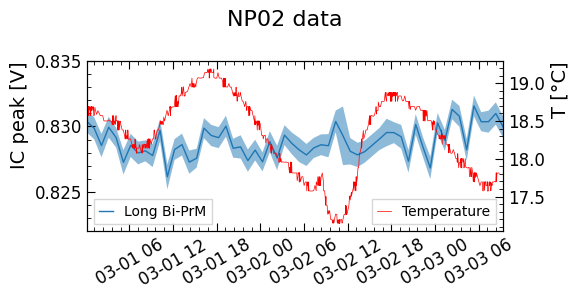

In [80]:
fig, ax = plt.subplots(figsize=(6, 3.), nrows=1, layout='tight')

ax.plot(Output.Date, Output.LongIC_Peak, lw=1, label='Long Bi-PrM')
ax.fill_between(Output.Date, Output.LongIC_Peak-Output.LongIC_PeakErr,  Output.LongIC_Peak+Output.LongIC_PeakErr, alpha=0.5)
pmana.utils.plotting.UpdateMatplotlibStyle(ax, None, 'IC peak [V]')

# ax.plot(Output_v2.Date, Output_v2.ShortIC_Peak, lw=1, label='Short Bi-PrM')
# ax.fill_between(Output_v2.Date, Output_v2.ShortIC_Peak-Output_v2.ShortIC_PeakErr,  Output_v2.ShortIC_Peak+Output_v2.ShortIC_PeakErr, alpha=0.5)

# gfx
ax.legend(frameon=True, fancybox=False, handlelength=1, fontsize=10, loc='lower left')
ax.tick_params(axis='x', labelrotation=30)
ax.set_xlim(Output['Date'].iloc[0], Output['Date'].iloc[-1])

# plot temperatures
a2 = ax.twinx()
a2.plot(Temperatures['Date'], Temperatures['T'], c='red', label='Temperature', lw=0.5, zorder=-3)
pmana.utils.plotting.UpdateMatplotlibStyle(a2, None, 'T [°C]')
a2.legend(frameon=True, fancybox=False, handlelength=1, fontsize=10, loc='lower right')

ax.set_ylim(0.822, 0.835)
# a2.set_ylim(16, 20)

fig.suptitle(f'NP02 data', fontsize=16)

plt.show()
fig.savefig(f"../../plots/cern/IC_Peaks_{TIME_DIR}.png", dpi=300, bbox_inches='tight')

#### Purity analysis, but save spectra 

This is not good practice. But can be super useful to check if the analysis did good.

In [81]:
# analyze campaign
TIME_DIR = f"2026_Mar"
PATH_CAMPAIGN = f"../../data/cern_csv/{TIME_DIR}"

CalibrationFactors = {
  0: 1,
  1: 1,
  2: 0.8,
  3: 0.8
}

Output = pmana.utils.iterators.IterateCERN_CSV(
    PATH_CAMPAIGN,  ###< path to data
    # pmana.utils.anatestdata.AnalyzeMeasurement, 
    functools.partial(
        pmana.purity.ana.ExtractICPeak, 
        CALIBRATION_FACTORS = CalibrationFactors,
        PM_TAG = 'Long',
        SAVE_SPECTRA = True, ###< save the spectra on the dataframe
        ANALYSIS_CONFIGURATION = ANALYSIS_CONFIGURATION
    )  ###< analyzing module, changing some options 
)

# convert top DataFrame
Output = pandas.DataFrame(Output)

# re-format the dataframe
Output.columns = [
  "LongIC_Peak", "LongIC_PeakErr", "LongIC_Scale",
  "xIC", "IC",
  "Date"
]

# sort by date
Output.sort_values(
    by = 'Date', 
    inplace = True,
    ignore_index = True
)

Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_00_10.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_01_11.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_02_11.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_03_11.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_04_12.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_05_12.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_06_12.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_07_13.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_08_13.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_09_13.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_10_14.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_11_14.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_12_14.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_13_15.csv...
Analyz

There were 4 used channels in this measurement.
Results for this measurement:
    LongIC_Peak  LongIC_PeakErr  LongIC_Scale  \
5     0.827262        0.000933      1.265556   

                                                 xIC  \
5  [0.203, 0.205, 0.207, 0.209, 0.211, 0.213, 0.2...   

                                                  IC                Date  
5  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ... 2026-03-01 05:12:00  


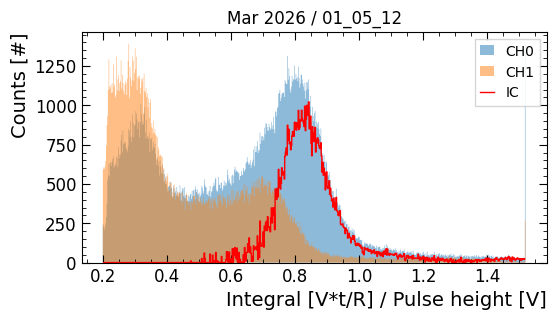

In [83]:
fig, ax = plt.subplots(figsize=(6,3))

YEAR = '2026'
MONTH = 'Mar'
MEASUREMENT = f'01_05_12'
FILE_PATH = f"../../data/cern_csv/{YEAR}_{MONTH}/Record_{YEAR}_{MONTH}_{MEASUREMENT}.csv"

# extract a measurement 
Data = pmana.utils.io.ExtractSingleMeasurement(
    FILE_PATH,
    IS_CSV = True,
    COL_NAMES = ['binCenter', 'F1', 'F2', 'F3', 'F4'],
    DELIMITER = ","
)
print(f"There were {len(Data)} used channels in this measurement.")

CHs = [1, 2]
for ch in CHs:
    # plot channel data
    pmana.utils.plotting.PlotSingleChannel(
        Data[ch-1],
        ax,
        channel = ch-1,
        rebin = False,
        debug = False,
        DISPLAY_FIT = False
    )

ax = pmana.utils.plotting.UpdateMatplotlibStyle(
    ax,
    "Integral [V*t/R] / Pulse height [V]",
    "Counts [#]"
)

# plot the corresponding IC peak
MONTH_ABBR = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
DAY, HOUR, MINUTE = MEASUREMENT.split('_')
EXACT_DATE = datetime.datetime(
    int(YEAR), 
    int(MONTH_ABBR[MONTH]),
    int(DAY),
    int(HOUR),
    int(MINUTE)
)
Mask = Output['Date'] == EXACT_DATE
print("Results for this measurement:\n", Output[Mask])
xIC = Output[Mask].iloc[0]['xIC']
IC = Output[Mask].iloc[0]['IC']
ax.step(
    xIC, 
    IC,
    where = 'mid',
    c = 'red',
    lw = 1,
    label = 'IC'
)

ax.legend(handlelength=1, loc='upper right', frameon=True, fancybox=False)
ax.set_title(f"{MONTH} {YEAR} / {MEASUREMENT}")
plt.show()
fig.savefig(f"../../plots/cern/RawData_IC_{YEAR}_{MONTH}.png", dpi=300, bbox_inches='tight')